In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

In [4]:
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [5]:
df = pd.read_csv('data.csv')
df.head()

,x,y
0,74.128461,357.046360
1,39.705725,206.225240
2,1.327203,2.163316
3,86.752451,412.080923
4,32.803825,171.032648


In [6]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (230, 2)


In [7]:
print("Column names:", df.columns.tolist())

Column names: ['x', 'y']


In [8]:
df.dtypes

x    float64
y    float64
dtype: object

In [9]:
df.head(10)

,x,y
0,74.128461,357.046360
1,39.705725,206.225240
2,1.327203,2.163316
3,86.752451,412.080923
4,32.803825,171.032648
5,82.203090,353.567737
6,43.325559,186.700912
7,15.793323,105.126081
8,50.544917,249.887001
9,45.902279,220.461495


In [10]:
df.tail(10)

,x,y
220,93.520051,509.240839
221,80.704001,190.956506
222,60.278873,199.887734
223,10.792489,-121.928951
224,88.555871,583.305692
225,46.424221,435.156719
226,21.129404,238.283335
227,27.307588,288.126693
228,57.563927,98.672413
229,98.118260,275.677750


In [11]:
df.describe()

,x,y
count,230.000000,230.000000
mean,51.570888,232.106834
std,29.750511,139.691624
min,0.626288,-121.928951
25%,26.916945,119.219180
50%,51.250974,237.056374
75%,77.840782,343.532195
max,99.816856,583.305692


In [12]:
print("Missing Values per column:")
print(df.isna().sum())

Missing Values per column:
x    0
y    0
dtype: int64


In [13]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicatd rows: {num_duplicates}")

Number of duplicatd rows: 0


In [14]:
print("x range:", df['x'].min(), "to", df['x'].max())
print("y range:", df['y'].min(), "to", df['y'].max())

x range: 0.6262881976694112 to 99.81685649702948
y range: -121.92895093094808 to 583.3056923127526


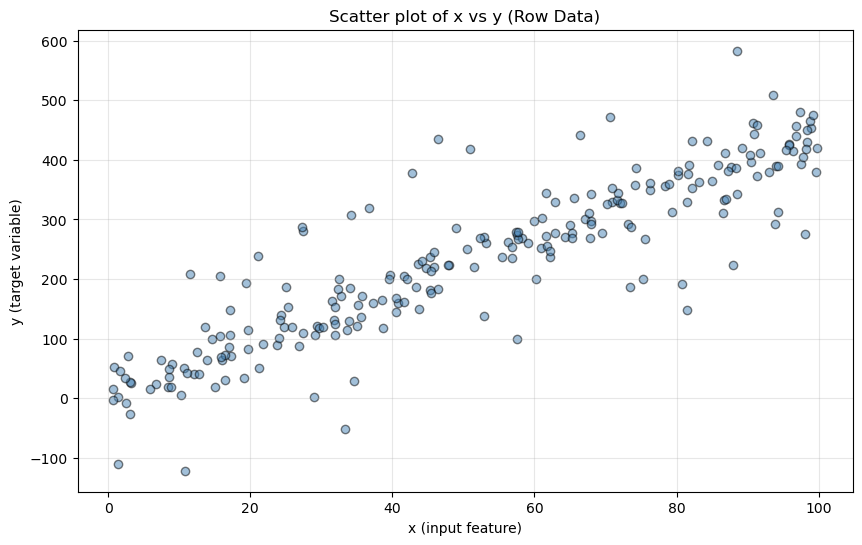

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], alpha=0.5, color='steelblue', edgecolors='k')
plt.title('Scatter plot of x vs y (Row Data)')
plt.xlabel('x (input feature)')
plt.ylabel('y (target variable)')
plt.grid(alpha=0.3)
plt.show()

In [16]:
correlation = df['x'].corr(df['y'])
print(f"Correlation between x and y: {correlation:.4f}")

Correlation between x and y: 0.8937


In [17]:
if correlation > 0.7:
    strength = 'a strong positive'
elif correlation > 0.3:
    strength = 'a moderate positive'
elif correlation > 0:
    strength = 'a week positive'
elif correlation > -0.3:
    strength = 'a week negative'
elif correlation > -0.7:
    strength = 'a moderate negative'
else:
    strength = 'a strong negative'

print(f"The correlation between x and y is {strength}")

The correlation between x and y is a strong positive


In [18]:
# pred(y) = wx + b
# where x = inut feature, y = target variable, w = weight(slope), b = bias (intercept)

In [19]:
X_all = df[['x']]
y_all = df['y']

baseline_lr = LinearRegression()
baseline_lr.fit(X_all, y_all)

baseline_weight = baseline_lr.coef_[0]
baseline_bias = baseline_lr.intercept_

print(f'Baseline linear regression weight (slope): {baseline_weight:.4f}')
print(f'Baseline linear regression bias (intercept): {baseline_bias:.4f}')
print(f'Baseline linear regression equation: y = {baseline_weight:.4f}* x + (baseline_bias:.4f)')
print(f'Baseline R^2 score: {baseline_lr.score(X_all, y_all):4f}')

Baseline linear regression weight (slope): 4.1965
Baseline linear regression bias (intercept): 15.6875
Baseline linear regression equation: y = 4.1965* x + (baseline_bias:.4f)
Baseline R^2 score: 0.798787


In [20]:
sample_row = df.iloc[0]
x_sample = sample_row['x']
y_actual = sample_row['y']

print(f"We picked row 0 from the dataset:")
print(f"   x (input) = {x_sample:.4f}")
print(f"   y (actual / true) = {y_actual:.4f}")

We picked row 0 from the dataset:
   x (input) = 74.1285
   y (actual / true) = 357.0464


In [21]:
w_demo = 2.0
b_demo = 0.0

y_hat_demo = w_demo * x_sample + b_demo
error_demo = y_actual - y_hat_demo

print(f"Choose weight w = {w_demo} and bias b = {b_demo}")
print(f"Prediction: y_hat = w * x + b = {w_demo} * {x_sample:.4f} + {b_demo} = {y_hat_demo:.4f}")
print(f"Actual y = {y_actual:.4f}")
print(f"Error (actual - Predicted) = {error_demo:.4f}")

Choose weight w = 2.0 and bias b = 0.0
Prediction: y_hat = w * x + b = 2.0 * 74.1285 + 0.0 = 148.2569
Actual y = 357.0464
Error (actual - Predicted) = 208.7894


In [22]:
x_input = df['x'].iloc[5]
y_true = df['y'].iloc[5]

weight_example = 3.0
bias_example = 1.0

prediction = x_input * weight_example + bias_example

print(f"input (x) = {x_input:.4f}")
print(f"weight (w) = {weight_example}")
print(f"bias (b) = {bias_example}")
print(f"prediction (y_hat) = input * weight + bias = {x_input:.4f}*{weight_example} + {bias_example} = {prediction:.4f}")
print(f"actual (y) = {y_true:.4f}")

input (x) = 82.2031
weight (w) = 3.0
bias (b) = 1.0
prediction (y_hat) = input * weight + bias = 82.2031*3.0 + 1.0 = 247.6093
actual (y) = 353.5677


In [23]:
X = df[['x']]
y = df['y']

print('Test of X:', type(X))
print('Test of y:', type(y))
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Test of X: <class 'pandas.core.frame.DataFrame'>
Test of y: <class 'pandas.core.series.Series'>
Shape of X: (230, 1)
Shape of y: (230,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (184, 1)
Shape of X_test: (46, 1)
Shape of y_train: (184,)
Shape of y_test: (46,)


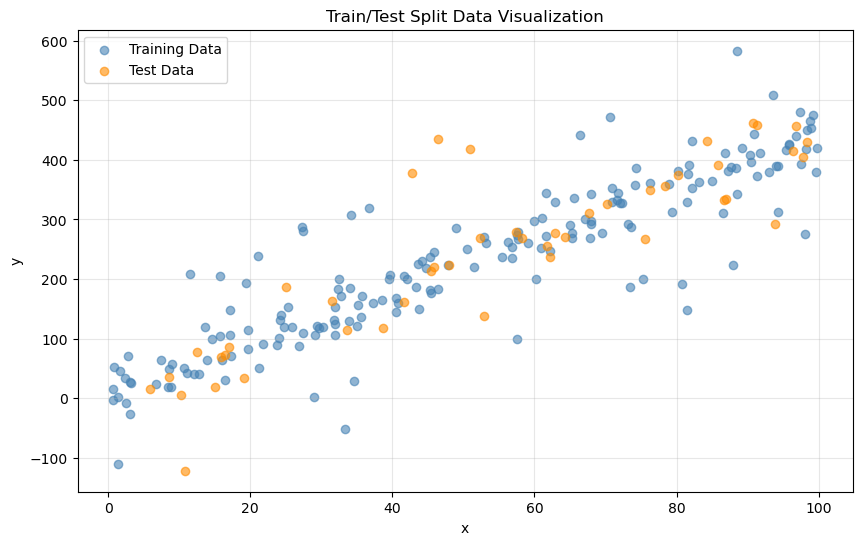

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.6, color='steelblue', label='Training Data')
plt.scatter(X_test, y_test, alpha=0.6, color='darkorange', label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Train/Test Split Data Visualization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
initial_weights = model.get_weights()
initial_w = initial_weights[0][0][0]
initial_b = initial_weights[1][0]

print(f"initial weight (w): {initial_w:.4f}")
print(f"initial bias (b): {initial_b:.4f}")

initial weight (w): -1.3871
initial bias (b): 0.0000


In [29]:
initial_predictions = model.predict(X_test, verbose=0)

comparison_before = pd.DataFrame({
    'x' : X_test['x'].values[:5],
    'Actual y' : y_test.values[:5],
    'Predicted y' : initial_predictions.flatten()[:5]
})

comparison_before

,x,Actual y,Predicted y
0,50.976094,418.016362,-70.708870
1,17.018219,85.076612,-23.605949
2,45.902279,220.461495,-63.670990
3,15.040591,19.226779,-20.862783
4,31.519201,162.627648,-43.720242


In [30]:
initial_loss = mean_squared_error(y_test, initial_predictions)
print(f"Initial MSE loss (before training): {initial_loss:.4f}")

Initial MSE loss (before training): 137327.3277


In [31]:
# error = actual - predicted
# squared_error = error^2
# MSE = average(squared_error) across all samples

In [32]:
sample = df.sample(3, random_state=1).reset_index(drop=True)
sample

,x,y
0,87.624681,387.588237
1,71.671607,332.754008
2,34.009957,184.754226


In [33]:
w_manual = 2.0
b_manual = 0.0

predictions_manual = w_manual * sample['x'] + b_manual
errors_manual = sample['y'] - predictions_manual
squared_errors_manual = errors_manual **2

manual_table = pd.DataFrame({
    'x': sample['x'],
    'Actual y': sample['y'],
    'Predicted y': predictions_manual,
    'Error (Actual - predicted)': errors_manual,
    'Squared Error': squared_errors_manual
})

manual_table

,x,Actual y,Predicted y,Error (Actual - predicted),Squared Error
0,87.624681,387.588237,175.249362,212.338875,45087.797659
1,71.671607,332.754008,143.343214,189.410794,35876.448855
2,34.009957,184.754226,68.019914,116.734312,13626.899695


In [34]:
mse_manual = squared_errors_manual.mean()
print(f"Step-by-step MSE over these 3 samples: {mse_manual:.4f}")

Step-by-step MSE over these 3 samples: 31530.3821


In [35]:
model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss = 'mse'
)

print("Model compiled successfully")

Model compiled successfully


In [36]:
history = model.fit(
    X_train, y_train,
    epochs = 100,
    verbose=0
)

print("Model training completed.")
print("Final training loss (MSE):", history.history['loss'][-1])

Model training completed.
Final training loss (MSE): 3808.349853515625


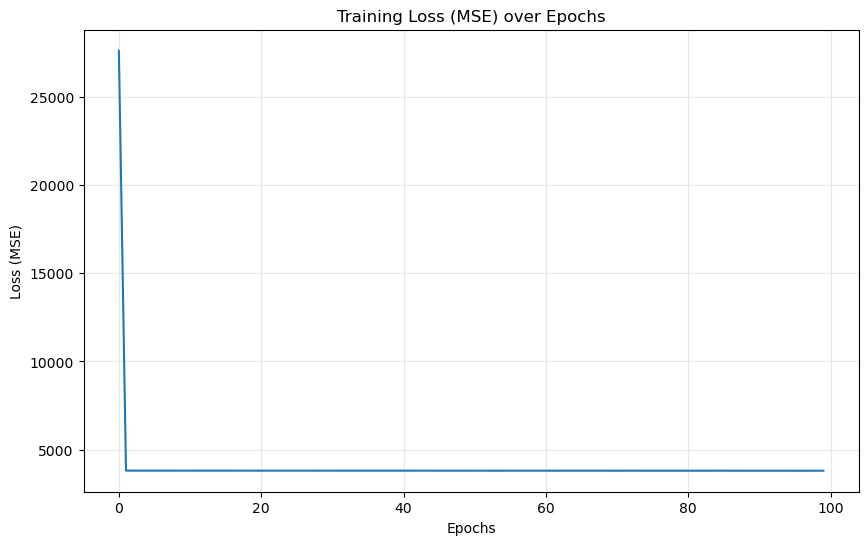

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Training Loss (MSE) over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(alpha=0.3)
plt.show()

In [38]:
learned_weights = model.get_weights()
learned_w = learned_weights[0][0][0]
learned_b = learned_weights[1][0]

print(f"Learned weight (w): {learned_w:.4f}")
print(f"learned bias (b): {learned_b:.4f}")

Learned weight (w): 4.3206
learned bias (b): 0.6524


In [39]:
comparison_table = pd.DataFrame({
    'Method': ['Linear Regression (sklearn)', 'Neural Network (TensorFlow)'],
    'Weight (w)': [baseline_weight, learned_w],
    'Bias (b)': [baseline_bias, learned_b],
})
comparison_table

,Method,Weight (w),Bias (b)
0,Linear Regression (sklearn),4.196540,15.687518
1,Neural Network (TensorFlow),4.320556,0.652382


In [40]:
test_predictions = model.predict(X_test, verbose=0).flatten()

results_df = pd.DataFrame({
    'x': X_test['x'].values,
    'Actual y': y_test.values,
    'Predicted y': test_predictions
})

results_df['error'] = results_df['Actual y'] - results_df['Predicted y']
results_df['absolute_error'] = results_df['error'].abs()

results_df.head(10)

,x,Actual y,Predicted y,error,absolute_error
0,50.976094,418.016362,220.897461,197.118901,197.118901
1,17.018219,85.076612,74.180550,10.896062,10.896062
2,45.902279,220.461495,198.975769,21.485726,21.485726
3,15.040591,19.226779,65.636101,-46.409322,46.409322
4,31.519201,162.627648,136.832870,25.794777,25.794777
5,45.469308,212.963876,197.105087,15.858788,15.858788
6,52.868194,137.343917,229.072388,-91.728471,91.728471
7,5.918196,15.966610,26.222279,-10.255668,10.255668
8,33.558574,113.975757,145.644089,-31.668332,31.668332
9,38.685300,117.955380,167.794403,-49.839023,49.839023


In [41]:
mse_value = mean_squared_error(y_test, test_predictions)
mae_value = mean_absolute_error(y_test, test_predictions)
rmse_value = np.sqrt(mse_value)
r2_value = r2_score(y_test, test_predictions)

print(f"Test MSE: {mse_value:.4f}")
print(f"Test MAE: {mae_value:.4f}")
print(f"Test RMSE: {rmse_value:.4f}")
print(f"Test R^2 score: {r2_value:.4f}")

Test MSE: 4959.2663
Test MAE: 45.9860
Test RMSE: 70.4221
Test R^2 score: 0.7724


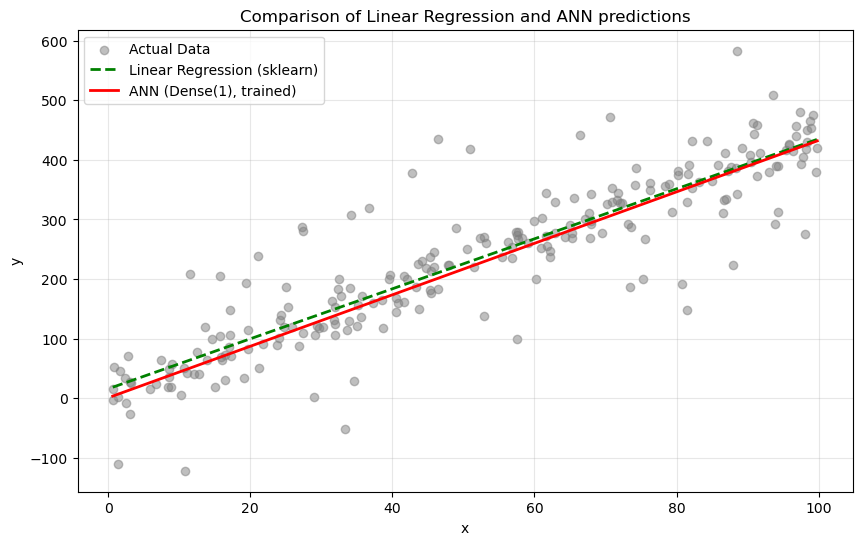

In [42]:
x_range = np.linspace(df['x'].min(), df['x'].max(), 100)

lr_line = baseline_weight * x_range + baseline_bias
ann_line = learned_w * x_range + learned_b

plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], alpha=0.5, color='gray', label='Actual Data')
plt.plot(x_range, lr_line, color='green', linewidth=2, linestyle='--', label='Linear Regression (sklearn)')
plt.plot(x_range, ann_line, color='red', linewidth=2, label='ANN (Dense(1), trained)')
plt.title('Comparison of Linear Regression and ANN predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

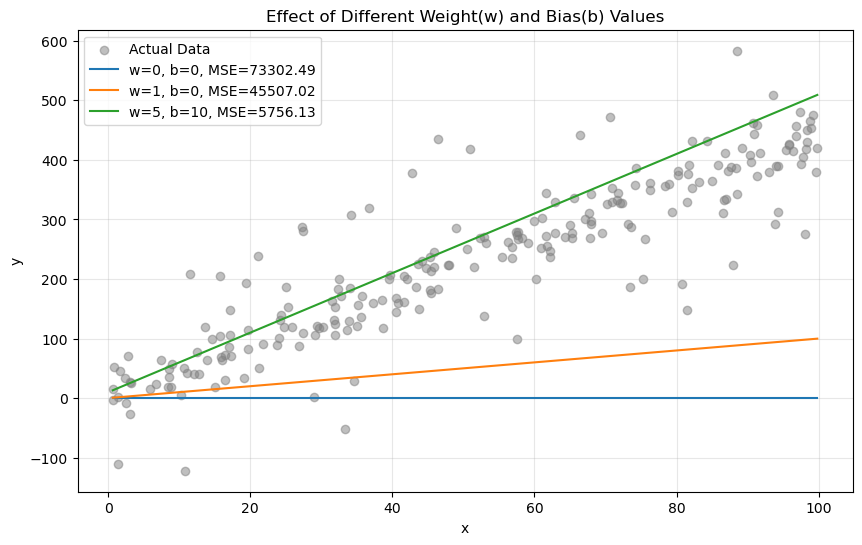

In [43]:
def evaluate_manual_line(w, b, X_vals, y_vals):
    predictions = w * X_vals + b
    mse = np.mean((y_vals - predictions) ** 2)
    return predictions, mse

manual_configs = [
    (0, 0),
    (1, 0),
    (5, 10)
]

x_vals = df['x'].values
y_vals = df['y'].values

plt.figure(figsize=(10, 6))
plt.scatter(x_vals, y_vals, alpha=0.5, color='gray', label='Actual Data')

x_line = np.linspace(df['x'].min(), df['x'].max(), 100)

for w_try, b_try in manual_configs:
    _, mse_try = evaluate_manual_line(w_try, b_try,x_vals, y_vals)
    line_y = w_try * x_line + b_try
    plt.plot(x_line, line_y, label=f'w={w_try}, b={b_try}, MSE={mse_try:.2f}')

plt.title('Effect of Different Weight(w) and Bias(b) Values')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

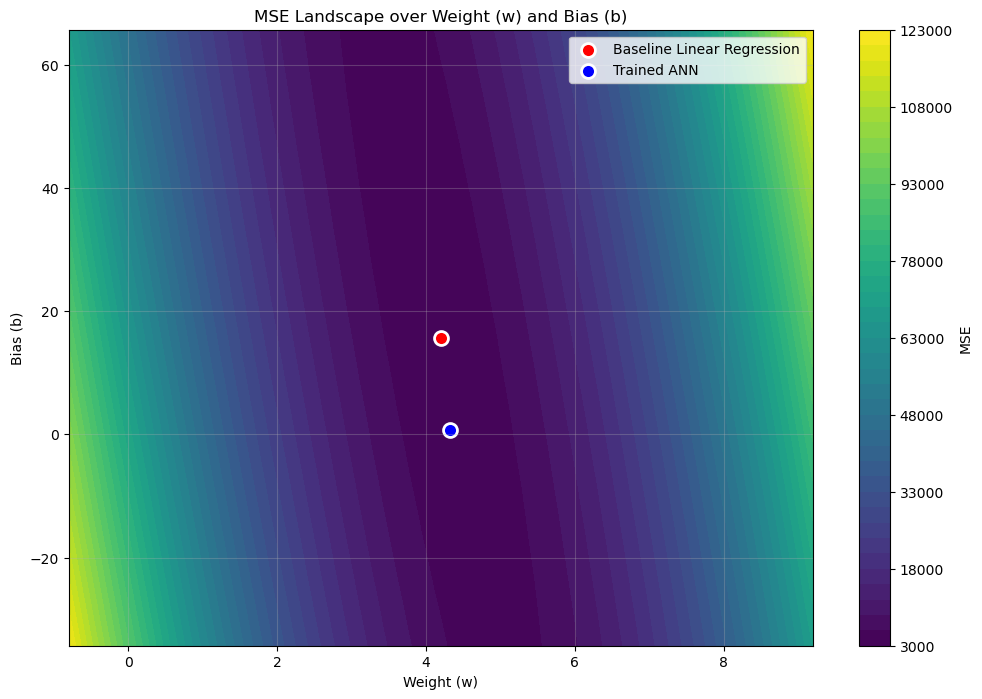

In [44]:
w_range = np.linspace(baseline_weight - 5, baseline_weight + 5, 60)
b_range = np.linspace(baseline_bias - 50, baseline_bias + 50, 60)

W_grid, B_grid = np.meshgrid(w_range, b_range)
MSE_grid = np.zeros_like(W_grid)

for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        w_g = W_grid[i, j]
        b_g = B_grid[i, j]
        preds_g = w_g * x_vals + b_g
        MSE_grid[i, j] = np.mean((y_vals - preds_g) **2)

plt.figure(figsize=(12, 8))
contour = plt.contourf(W_grid, B_grid, MSE_grid, levels=40, cmap='viridis')
plt.colorbar(contour, label='MSE')
plt.scatter(baseline_weight, baseline_bias, color='red', s=100, label='Baseline Linear Regression', edgecolor='white', linewidth=2)
plt.scatter(learned_w, learned_b, color='blue', s=100, label='Trained ANN', edgecolor='white', linewidth=2)
plt.title('MSE Landscape over Weight (w) and Bias (b)')
plt.xlabel('Weight (w)')
plt.ylabel('Bias (b)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
def build_and_train_model(learning_rate, epochs= 100, seed=42):
    tf.random.set_seed(seed)
    m = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=[1])])
    m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss='mse')
    h = m.fit(X_train, y_train, epochs=epochs, verbose=0)
    return m, h

In [46]:
learning_rates_to_try = [0.00001, 0.0001, 0.001]
lr_histories = {}

for lr in learning_rates_to_try:
    _, h = build_and_train_model(lr)
    lr_histories[lr] = h.history['loss']
    print(f"Learning rate {lr} completed. Final training loss: {h.history['loss'][-1]:.4f}")
    

Learning rate 1e-05 completed. Final training loss: 3752.3479
Learning rate 0.0001 completed. Final training loss: 3808.6438
Learning rate 0.001 completed. Final training loss: nan


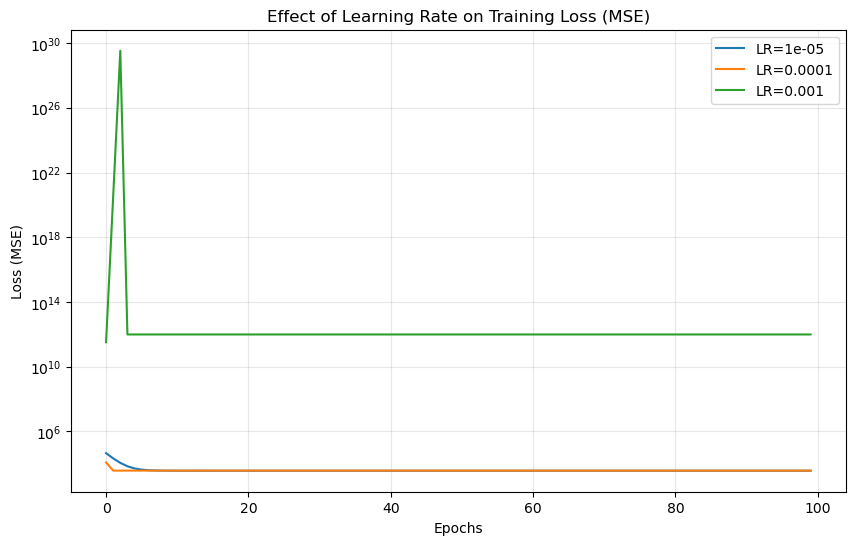

In [47]:
plt.figure(figsize=(10, 6))
for lr, losses in lr_histories.items():
    clean_losses = [1e12 if (not np.isfinite(v)) else v for v in losses]
    plt.plot(clean_losses, label=f'LR={lr}')

plt.title('Effect of Learning Rate on Training Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
epoch_options = [1, 10, 50, 100]
epoch_results = []

for n_epochs in epoch_options:
    m, h = build_and_train_model(learning_rate=0.0001, epochs=n_epochs)
    w_e, b_e = m.get_weights()[0][0][0], m.get_weights()[1][0]
    final_loss_e = h.history['loss'][-1]
    epoch_results.append({
        'Epochs': n_epochs,
        'Final Training Loss (MSE)': final_loss_e,
        'Learned Weight (w)': w_e,
        'Learned Bias (b)': b_e
    })
    
epoch_results_df = pd.DataFrame(epoch_results)
epoch_results_df

,Epochs,Final Training Loss (MSE),Learned Weight (w),Learned Bias (b)
0,1,16047.902344,4.328782,0.062001
1,10,3813.101318,4.328781,0.133694
2,50,3811.146729,4.325428,0.345161
3,100,3808.472900,4.320772,0.638795


In [53]:
tf.random.set_seed(42)
hidden_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(1)
])

hidden_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
hidden_model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
hidden_history = hidden_model.fit(X_train, y_train, epochs=100, verbose=0)
hidden_predictions = hidden_model.predict(X_test, verbose=0).flatten()
hidden_mse = mean_squared_error(y_test, hidden_predictions)

print(f"Hidden layer model MSE on test set: {hidden_mse:.4f}")
print(f"Original Dense(1) model MSE on test set: {mse_value:.4f}")

Hidden layer model MSE on test set: 13281.5572
Original Dense(1) model MSE on test set: 4959.2663


Shape of the dataset: (230, 2)
                x           y
count  230.000000  230.000000
mean    51.570888  232.106834
std     29.750511  139.691624
min      0.626288 -121.928951
25%     26.916945  119.219180
50%     51.250974  237.056374
75%     77.840782  343.532195
max     99.816856  583.305692


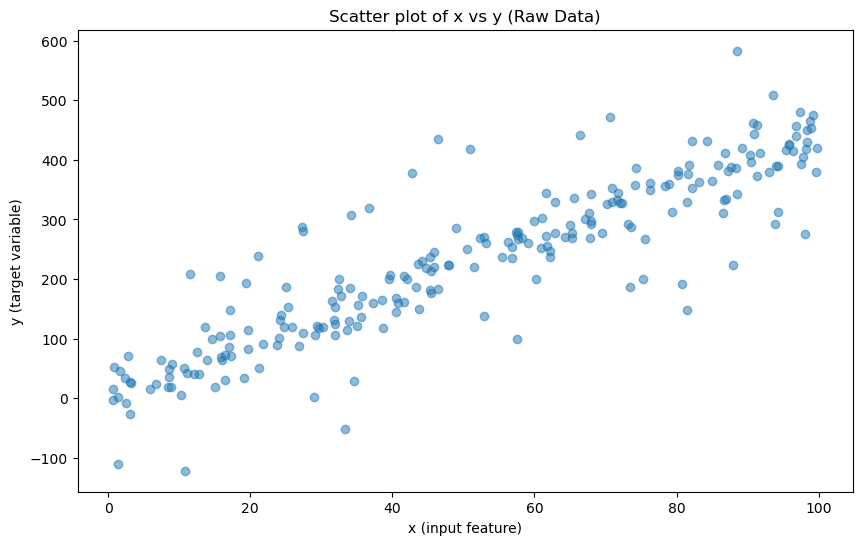

Initial weight (w): -0.6371
Initial bias (b): 0.0000
Learned weight (w): 4.3207
Learned bias (b): 0.6422
Test MSE: 4959.2421
Test MAE: 45.9854
Test RMSE: 70.4219
Test R^2 score: 0.7724


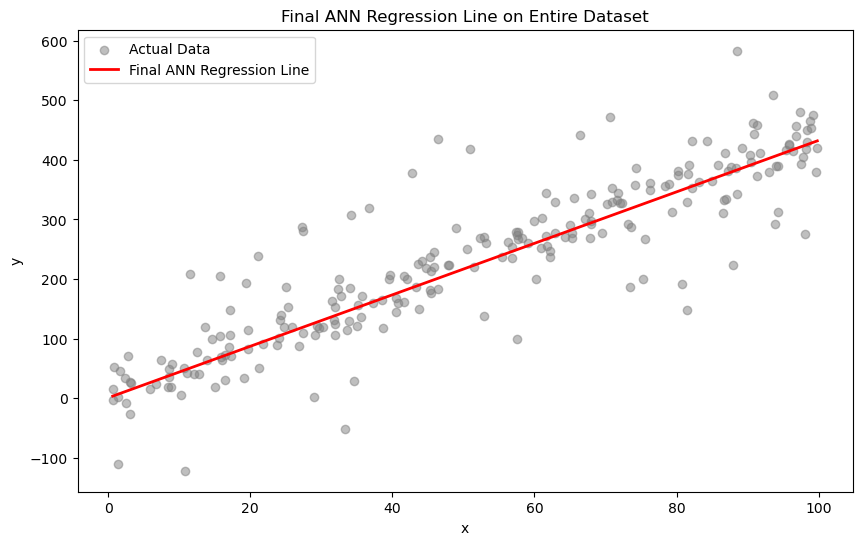

In [56]:
# 1. Imort libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

# 2. Load the dataset
df_final = pd.read_csv('data.csv')

# 3. Inspect the dataset
print("Shape of the dataset:", df_final.shape)
print(df_final.describe())

# 4. Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(df_final['x'], df_final['y'], alpha=0.5)
plt.title('Scatter plot of x vs y (Raw Data)')
plt.xlabel('x (input feature)')
plt.ylabel('y (target variable)')
plt.show()

# 5. Split the dataset into training and testing sets
X_final = df_final[['x']]
y_final = df_final['y']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# 6. Build Dense(1) model
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

# 7. Inspect initial weights
w0, b0 = final_model.get_weights()[0][0][0], final_model.get_weights()[1][0]
print(f"Initial weight (w): {w0:.4f}")
print(f"Initial bias (b): {b0:.4f}")

# 8. Compile
final_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001), loss='mse')

# 9. Train
final_history = final_model.fit(X_train_f,y_train_f, epochs=100, verbose=0)

# 10. Inspect learned weights
w_learned, b_learned = final_model.get_weights()[0][0][0], final_model.get_weights()[1][0]
print(f"Learned weight (w): {w_learned:.4f}")
print(f"Learned bias (b): {b_learned:.4f}")


# 11. Predict
final_preds = final_model.predict(X_test_f, verbose=0).flatten()

# 12. Evaluate
print(f"Test MSE: {mean_squared_error(y_test_f, final_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_f, final_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_f, final_preds)):.4f}")
print(f"Test R^2 score: {r2_score(y_test_f, final_preds):.4f}")

# 13. Plot final regression line
x_line_f = np.linspace(df_final['x'].min(), df_final['x'].max(), 100)
y_line_f = w_learned * x_line_f + b_learned

plt.figure(figsize=(10, 6))
plt.scatter(df_final['x'], df_final['y'], alpha=0.5, color='gray', label='Actual Data')
plt.plot(x_line_f, y_line_f, color='red', linewidth=2, label='Final ANN Regression Line')
plt.title('Final ANN Regression Line on Entire Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()